# Reducción de dimensionalidad con Independent Component Analysis (ICA)

Ejemplo de aplicación de Independent Component Analysis (ICA) para reducir la dimensionalidad del conjunto de datos MNIST utilizado previamente en el ejemplo de PCA.

Este Notebook ha sido preparado para el curso de aprendizaje de máquinas no supervisado de la Especialización en Machine Learning de la Universidad del Magdalena.

MNIST contiene imágenes de dígitos escritos a mano de 28x28 píxeles. Al considerar cada píxel como una variable, cada imagen queda representada originalmente mediante, 28 x 28 = 784,  características.

Este dataset se puede descargar desde: http://yann.lecun.com/exdb/mnist/

ICA busca una transformación lineal que produzca componentes tan estadísticamente independientes como sea posible.

In [1]:
import os
import gzip
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kurtosis
from sklearn.decomposition import FastICA, PCA
from sklearn.exceptions import ConvergenceWarning

%matplotlib inline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1. Carga y exploración de los datos

Se utilizará el mismo archivo `mnist.pkl.gz` del ejemplo de PCA. El archivo debe estar en la misma carpeta que este Notebook y contiene tres particiones:

- entrenamiento: 50 000 ejemplos;
- validación: 10 000 ejemplos;
- prueba: 10 000 ejemplos.

Cualquier transformación debe ajustarse únicamente con el conjunto de entrenamiento. Validación y prueba se transforman posteriormente con el modelo ya ajustado, evitando así fuga de información.

In [2]:
# Cargamos MNIST desde el archivo utilizado en el ejemplo de PCA.
ruta_archivo = os.path.join(os.getcwd(), "mnist.pkl.gz")

if not os.path.exists(ruta_archivo):
    raise FileNotFoundError(
        "No se encontró 'mnist.pkl.gz'. "
        "Coloque el archivo en la misma carpeta del Notebook."
    )

with gzip.open(ruta_archivo, "rb") as f:
    train_set, validation_set, test_set = pickle.load(f, encoding="latin1")

X_train_np, y_train_np = train_set
X_validation_np, y_validation_np = validation_set
X_test_np, y_test_np = test_set

print("Entrenamiento:", X_train_np.shape)
print("Validación:   ", X_validation_np.shape)
print("Prueba:       ", X_test_np.shape)

Entrenamiento: (50000, 784)
Validación:    (10000, 784)
Prueba:        (10000, 784)


In [3]:
# Convertimos los arreglos en objetos de pandas y usamos índices no repetidos.
train_index = range(0, len(X_train_np))
validation_index = range(
    len(X_train_np),
    len(X_train_np) + len(X_validation_np)
)
test_index = range(
    len(X_train_np) + len(X_validation_np),
    len(X_train_np) + len(X_validation_np) + len(X_test_np)
)

X_train = pd.DataFrame(X_train_np, index=train_index)
y_train = pd.Series(y_train_np, index=train_index, name="Etiqueta")

X_validation = pd.DataFrame(X_validation_np, index=validation_index)
y_validation = pd.Series(
    y_validation_np, index=validation_index, name="Etiqueta"
)

X_test = pd.DataFrame(X_test_np, index=test_index)
y_test = pd.Series(y_test_np, index=test_index, name="Etiqueta")

print("Rango de los píxeles:",
      float(X_train.min().min()), "a", float(X_train.max().max()))
print("Clases:", sorted(y_train.unique()))

Rango de los píxeles: 0.0 a 0.99609375
Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


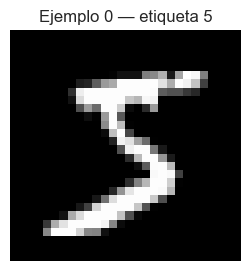

In [4]:
def ver_digito(X, y, ejemplo):
    """Muestra una imagen 28x28 y su etiqueta."""
    etiqueta = int(y.loc[ejemplo])
    imagen = X.loc[ejemplo].to_numpy().reshape(28, 28)

    plt.figure(figsize=(3, 3))
    plt.imshow(imagen, cmap="gray")
    plt.title(f"Ejemplo {ejemplo} — etiqueta {etiqueta}")
    plt.axis("off")
    plt.show()


ver_digito(X_train, y_train, 0)

## 2. Preprocesamiento

### 2.1 Eliminar variables constantes

Muchos píxeles de los bordes permanecen en cero para todas las imágenes. Estas variables tienen varianza cero y hacen que la matriz de covarianza sea singular. Antes de aplicar ICA se filtrarán estas variables únicamente utilizando el conjunto de entrenamiento y luego se eliminarán de las otras tres particiones usando la misma máscara.

In [6]:
# La máscara se calcula SOLO con entrenamiento.
varianza_pixeles = X_train.var(axis=0) #Estimación de la varianza para cada una de las variables
mascara_no_constante = varianza_pixeles > 0

X_train_nc = X_train.loc[:, mascara_no_constante]
X_validation_nc = X_validation.loc[:, mascara_no_constante]
X_test_nc = X_test.loc[:, mascara_no_constante]

print("Variables originales:       ", X_train.shape[1])
print("Variables constantes:       ", int((~mascara_no_constante).sum()))
print("Variables después del filtro:", X_train_nc.shape[1])

Variables originales:        784
Variables constantes:        67
Variables después del filtro: 717


## 3. ICA para visualización en dos dimensiones

Primero se ajustará un modelo con dos componentes para representar cada imagen. 

In [16]:
X_ajuste_ica = X_train_nc

In [17]:
ica_2d = FastICA(
    n_components=2,
    algorithm="parallel",
    whiten="unit-variance",
    fun="logcosh",
    max_iter=1000,
    tol=1e-4,
    random_state=RANDOM_STATE
)

with warnings.catch_warnings():
    warnings.simplefilter("always", ConvergenceWarning)
    ica_2d.fit(X_ajuste_ica)

X_train_ica_2d = pd.DataFrame(
    ica_2d.transform(X_train_nc),
    index=X_train_nc.index,
    columns=["IC1", "IC2"]
)

X_validation_ica_2d = pd.DataFrame(
    ica_2d.transform(X_validation_nc),
    index=X_validation_nc.index,
    columns=["IC1", "IC2"]
)

X_test_ica_2d = pd.DataFrame(
    ica_2d.transform(X_test_nc),
    index=X_test_nc.index,
    columns=["IC1", "IC2"]
)

print("Dimensión original:", X_train_nc.shape)
print("Dimensión reducida:", X_train_ica_2d.shape)
print("Iteraciones realizadas:", ica_2d.n_iter_)

Dimensión original: (50000, 717)
Dimensión reducida: (50000, 2)
Iteraciones realizadas: 4


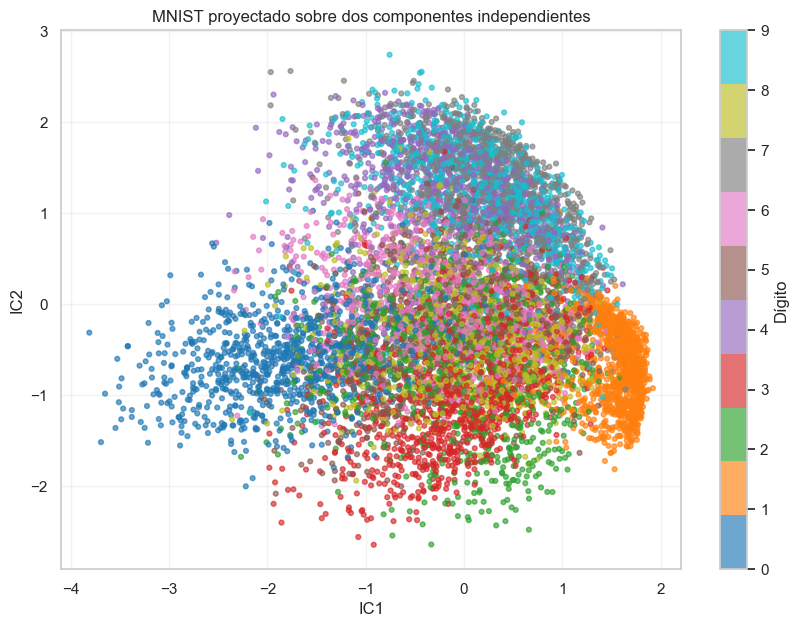

In [18]:
def grafico_componentes(X_reducido, y, titulo, muestra=10_000):
    """Grafica dos componentes coloreadas por etiqueta."""
    datos = X_reducido.join(y, how="inner")

    if muestra is not None and len(datos) > muestra:
        datos = datos.sample(n=muestra, random_state=RANDOM_STATE)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        datos.iloc[:, 0],
        datos.iloc[:, 1],
        c=datos["Etiqueta"],
        cmap="tab10",
        s=12,
        alpha=0.65
    )
    plt.xlabel(datos.columns[0])
    plt.ylabel(datos.columns[1])
    plt.title(titulo)
    plt.colorbar(scatter, ticks=range(10), label="Dígito")
    plt.grid(alpha=0.25)
    plt.show()


grafico_componentes(
    X_train_ica_2d,
    y_train,
    "MNIST proyectado sobre dos componentes independientes"
)

### Interpretación

Cada punto representa una imagen y el color corresponde a su etiqueta real.

- Una separación parcial de colores indica que la representación conserva cierta estructura útil.
- El solapamiento entre clases no implica que ICA haya fallado: su objetivo no es maximizar la separación entre las
  clases.
- El orden y el signo de `IC1` e `IC2` no tienen interpretación única.

## 4. Comprobaciones sobre las componentes

### 4.1 Correlación

Si las componentes fueran independientes, necesariamente deberían estar no correlacionadas. Sin embargo, correlación cero por sí sola no demuestra independencia.

In [19]:
correlacion_ica = X_train_ica_2d.corr()

print("Matriz de correlación de las componentes ICA:")
display(correlacion_ica.round(6))

Matriz de correlación de las componentes ICA:


,IC1,IC2
IC1,1.0,0.0
IC2,0.0,1.0


### 4.2 No gaussianidad

FastICA busca proyecciones con alta no gaussianidad mediante una aproximación de la negentropía. Para comprobar la no gaussinidad calculemos la curtosis de Fisher, teniendo en cuenta que una distribución gaussiana tiene curtosis de Fisher cercana a cero; y que valores alejados de cero sugieren no gaussianidad.

In [21]:
curtosis_ica = kurtosis(X_train_ica_2d.to_numpy(), axis=0,fisher=True, bias=False)
for nombre, valor in zip(X_train_ica_2d.columns, curtosis_ica):
    print(f"Curtosis de {nombre}: {valor:.4f}")

Curtosis de IC1: 0.2295
Curtosis de IC2: -0.7016


IC1 presenta una curtosis de (0.2295), mientras que IC2 (−0.7016). Como ambos valores son distintos de cero, las dos componentes muestran cierta no gaussianidad; IC2 se aleja más de la normal según la magnitud de su curtosis.

## 5. Reducción a un número intermedio de componentes

Para una reducción dimensional utilizable en tareas posteriores elegiremos manualmente \(k=50\):

A diferencia de PCA, ICA no ofrece un porcentaje de varianza explicada para seleccionar automáticamente \(k\). El número debe escogerse según el objetivo, el costo computacional, la reconstrucción o el desempeño de una tarea posterior.

In [22]:
N_COMPONENTES = 50

ica = FastICA(
    n_components=N_COMPONENTES,
    algorithm="parallel",
    whiten="unit-variance",
    fun="logcosh",
    max_iter=1500,
    tol=1e-4,
    random_state=RANDOM_STATE
)

with warnings.catch_warnings():
    warnings.simplefilter("always", ConvergenceWarning)
    X_ajuste_ica_reducido = ica.fit_transform(X_ajuste_ica)

X_train_ica = pd.DataFrame(
    ica.transform(X_train_nc),
    index=X_train_nc.index,
    columns=[f"IC{i+1}" for i in range(N_COMPONENTES)]
)

X_validation_ica = pd.DataFrame(
    ica.transform(X_validation_nc),
    index=X_validation_nc.index,
    columns=X_train_ica.columns
)

X_test_ica = pd.DataFrame(
    ica.transform(X_test_nc),
    index=X_test_nc.index,
    columns=X_train_ica.columns
)

print("Entrenamiento original:", X_train_nc.shape)
print("Entrenamiento reducido:", X_train_ica.shape)
print("Validación reducida:   ", X_validation_ica.shape)
print("Prueba reducida:       ", X_test_ica.shape)
print("Iteraciones realizadas:", ica.n_iter_)

Entrenamiento original: (50000, 717)
Entrenamiento reducido: (50000, 50)
Validación reducida:    (10000, 50)
Prueba reducida:        (10000, 50)
Iteraciones realizadas: 103


## 6. Visualización de patrones asociados con las componentes

En `scikit-learn`, `mixing_` aproxima la matriz de mezcla. Cada columna indica cómo una fuente independiente estimada contribuye a las variables observadas.

Al devolver los coeficientes a las 784 posiciones originales, podemos visualizarlos como imágenes de 28x28. Estos mapas pueden revelar trazos, regiones o contrastes frecuentes, pero no deben interpretarse automáticamente como dígitos completos.

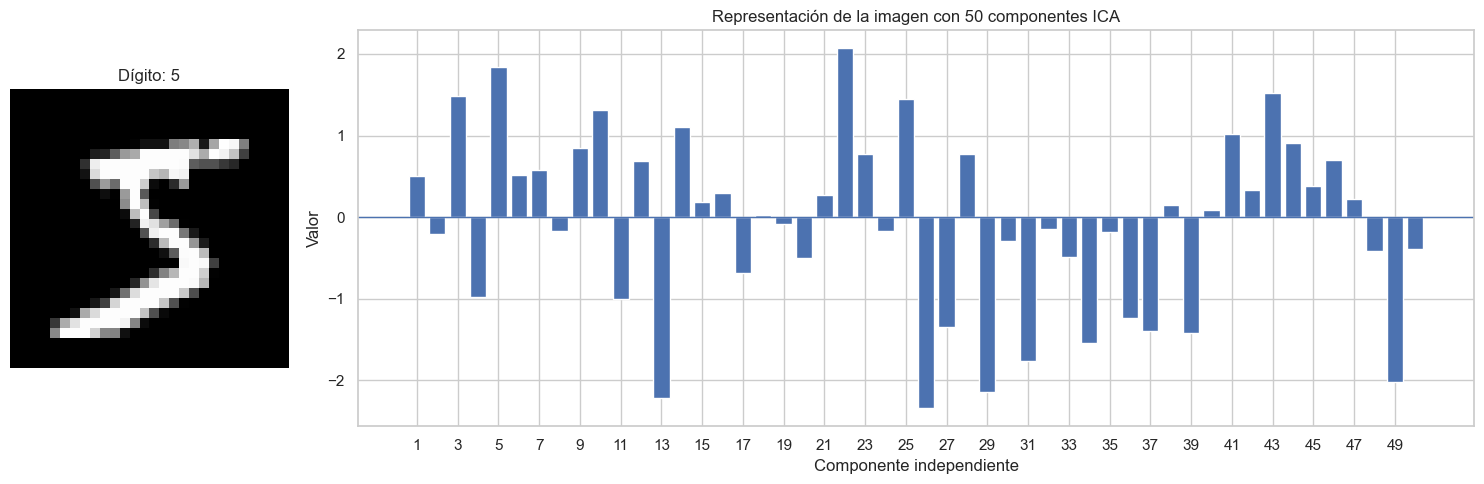

In [25]:
ejemplo = 0

imagen = X_train.loc[ejemplo].to_numpy().reshape(28, 28)
valores_componentes = X_train_ica.loc[ejemplo]

fig, ejes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 4]})

ejes[0].imshow(imagen, cmap="gray")
ejes[0].set_title(f"Dígito: {int(y_train.loc[ejemplo])}")
ejes[0].axis("off")

ejes[1].bar(range(1, N_COMPONENTES + 1), valores_componentes)
ejes[1].axhline(0, linewidth=1)
ejes[1].set_xlabel("Componente independiente")
ejes[1].set_ylabel("Valor")
ejes[1].set_title("Representación de la imagen con 50 componentes ICA")
ejes[1].set_xticks(range(1, N_COMPONENTES + 1, 2))

plt.tight_layout()
plt.show()

## 7. Reconstrucción aproximada de imágenes

Aunque ICA se orienta a separar fuentes y no a minimizar el error de reconstrucción, `inverse_transform` permite regresar aproximadamente al espacio de los píxeles. La reconstrucción utiliza solo las 50 componentes conservadas.

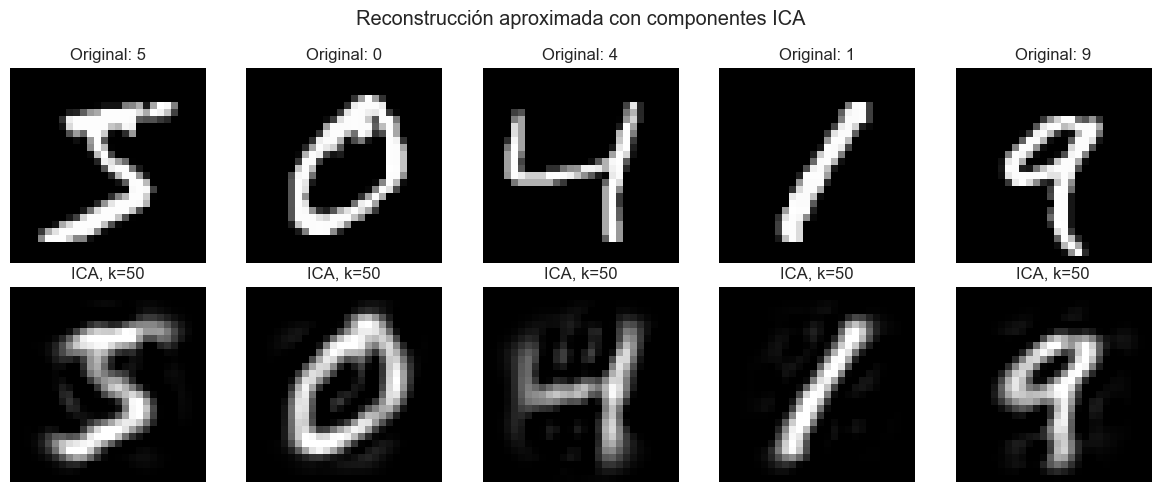

In [26]:
# Seleccionamos varios ejemplos de entrenamiento.
ejemplos = [0, 1, 2, 3, 4]

X_ejemplos_nc = X_train_nc.loc[ejemplos]
S_ejemplos = ica.transform(X_ejemplos_nc)
X_reconstruido_nc = ica.inverse_transform(S_ejemplos)

# Reinsertamos las variables constantes eliminadas.
X_reconstruido = np.zeros((len(ejemplos), X_train.shape[1]))
X_reconstruido[:, mascara_no_constante.to_numpy()] = X_reconstruido_nc

fig, ejes = plt.subplots(2, len(ejemplos), figsize=(12, 5))

for j, ejemplo in enumerate(ejemplos):
    original = X_train.loc[ejemplo].to_numpy().reshape(28, 28)
    reconstruida = X_reconstruido[j].reshape(28, 28)

    ejes[0, j].imshow(original, cmap="gray", vmin=0, vmax=1)
    ejes[0, j].set_title(f"Original: {int(y_train.loc[ejemplo])}")
    ejes[0, j].axis("off")

    ejes[1, j].imshow(reconstruida, cmap="gray", vmin=0, vmax=1)
    ejes[1, j].set_title("ICA, k=50")
    ejes[1, j].axis("off")

plt.suptitle("Reconstrucción aproximada con componentes ICA")
plt.tight_layout()
plt.show()

In [27]:
# Error cuadrático medio de reconstrucción en una muestra de entrenamiento.
n_evaluacion = min(5_000, len(X_train_nc))
X_eval = X_train_nc.sample(n=n_evaluacion, random_state=RANDOM_STATE)

S_eval = ica.transform(X_eval)
X_eval_reconstruido = ica.inverse_transform(S_eval)

mse_ica = np.mean(
    (X_eval.to_numpy() - X_eval_reconstruido) ** 2
)

print(f"MSE de reconstrucción ICA con {N_COMPONENTES} componentes: {mse_ica:.6f}")

MSE de reconstrucción ICA con 50 componentes: 0.012704


## 8. Actividades propuestas

1. Cambie `N_COMPONENTES` a 20, 100 y 150. Compare el tiempo de ajuste y el error de reconstrucción.
2. Cambie `fun="logcosh"` por `"exp"` o `"cube"` y observe si cambia la convergencia.
3. Utilice ICA para los datos sintéticos del ejemplo `"ejemplo_sintetico_pca_vs_kernelpca"` y analice los resultados en comparación con PCA, y PCA kernel.